<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/van%20Binsbergen%2C%20J.%20H.%2C%20Hua%2C%20S.%2C%20Wachter%2C%20J.%20A.%2C%20%26%20Peeters%2C%20J.%20(2020).%20Is%20the%20United%20States%20a%20lucky%20survivor%20A%20hierarchical%20Bayesian%20approach/Is_the_US_a_lucky_survivor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook does not directly use data. It is used to show the statistical properties that cause the US to be seen as an outlier.

In [6]:
!pip install pymc numpy pandas arviz


**Simulating survivorship bias**

Countries that avoid crashes purely by chance will show much higher average returns,
mimicking the U.S. outperformance documented in the paper.

Countries simulated: 30
Lucky survivors (no crashes in 100 yrs): 2


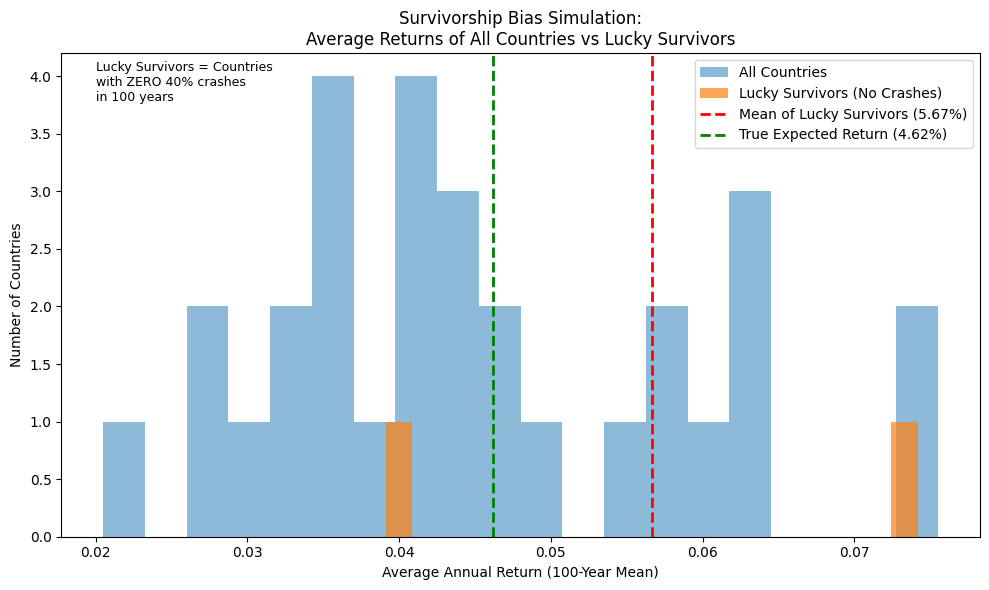

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
n_countries = 30
years = 100
true_crash_prob = 0.03       # annual crash probability
crash_size = -0.40           # 40% crash
normal_mu = 0.06             # normal return mean
normal_sigma = 0.15          # normal return volatility

def simulate_country():
    returns = []
    for t in range(years):
        if np.random.rand() < true_crash_prob:
            returns.append(crash_size)
        else:
            returns.append(np.random.normal(normal_mu, normal_sigma))
    return np.array(returns)

# Simulate all countries
data = np.vstack([simulate_country() for _ in range(n_countries)])

# Identify "lucky survivors" (no crashes)
survivors = data[np.sum(data == crash_size, axis=1) == 0]

print(f"Countries simulated: {n_countries}")
print(f"Lucky survivors (no crashes in 100 yrs): {survivors.shape[0]}")

# Compute averages
avg_all = data.mean(axis=1)
avg_survivors = survivors.mean(axis=1)

true_mean = (
    true_crash_prob * crash_size
    + (1 - true_crash_prob) * normal_mu
)
# Plot
plt.figure(figsize=(10,6))

plt.hist(avg_all, bins=20, alpha=0.5, label='All Countries')
plt.hist(avg_survivors, bins=20, alpha=0.7, label='Lucky Survivors (No Crashes)')

plt.axvline(avg_survivors.mean(),
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Mean of Lucky Survivors ({avg_survivors.mean():.2%})')

plt.axvline(true_mean,
            color='green',
            linestyle='--',
            linewidth=2,
            label=f'True Expected Return ({true_mean:.2%})')

plt.xlabel("Average Annual Return (100-Year Mean)")
plt.ylabel("Number of Countries")
plt.title("Survivorship Bias Simulation:\nAverage Returns of All Countries vs Lucky Survivors")

plt.text(0.02, plt.ylim()[1]*0.9,
         "Lucky Survivors = Countries\nwith ZERO 40% crashes\nin 100 years",
         fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

This code simulates 100 years of annual returns for 30 countries, each with a small chance of a 40% crash or otherwise normal returns, to illustrate **survivorship bias**. It identifies “lucky survivors” that avoid crashes entirely and compares their average returns to all countries, showing how only looking at survivors can overstate expected performance.


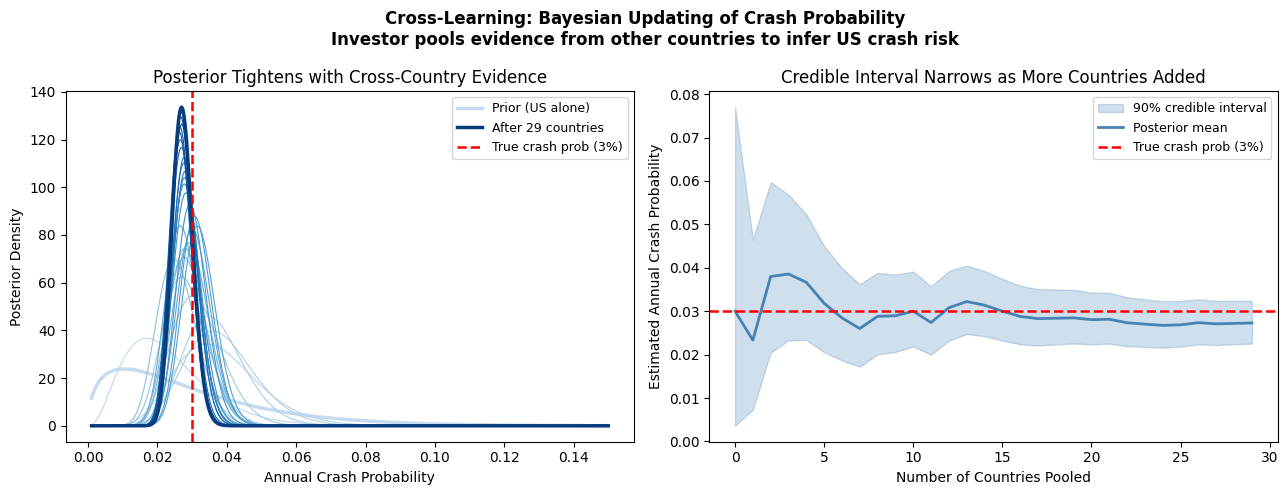

Prior mean:               0.0300
Posterior mean:           0.0273  (after 29 countries)
90% CI:                   [0.0225, 0.0324]
Total crash-years seen:   79 / 2900


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

np.random.seed(42)

# ── Parameters ────────────────────────────────────────────────────────────────
n_countries  = 29
years        = 100
true_crash_p = 0.03
a0, b0       = 1.5, 48.5    # prior mean = 1.5/50 = 3%

# ── Simulate: for each country, count how many of its 100 years were crashes ──
# np.random.binomial(trials, prob, size) → each value ≈ 3 crashes per century
crashes_per_country = np.random.binomial(years, true_crash_p, n_countries)

p_grid = np.linspace(0.001, 0.15, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Cross-Learning: Bayesian Updating of Crash Probability\n"
             "Investor pools evidence from other countries to infer US crash risk",
             fontsize=12, fontweight="bold")

# ── Left panel: posterior density evolving as countries are added ─────────────
ax = axes[0]
a, b = a0, b0
colors = plt.cm.Blues(np.linspace(0.25, 0.95, n_countries + 1))

for i in range(n_countries + 1):
    pdf = beta.pdf(p_grid, a, b)
    lw  = 2.5 if i in (0, n_countries) else 0.8
    lbl = ("Prior (US alone)"          if i == 0
           else f"After {n_countries} countries" if i == n_countries
           else None)
    ax.plot(p_grid, pdf, color=colors[i], lw=lw, label=lbl)
    if i < n_countries:
        a += crashes_per_country[i]           # crash years → update a
        b += years - crashes_per_country[i]   # non-crash years → update b

ax.axvline(true_crash_p, color="red", ls="--", lw=1.8,
           label=f"True crash prob ({true_crash_p:.0%})")
ax.set_xlabel("Annual Crash Probability")
ax.set_ylabel("Posterior Density")
ax.set_title("Posterior Tightens with Cross-Country Evidence")
ax.legend(fontsize=9)

# ── Right panel: posterior mean + 90% CI as countries accumulate ──────────────
ax2 = axes[1]
a, b = a0, b0    # fresh reset — independent of left panel
means, lo, hi = [], [], []

for i in range(n_countries + 1):
    means.append(a / (a + b))
    lo.append(beta.ppf(0.05, a, b))
    hi.append(beta.ppf(0.95, a, b))
    if i < n_countries:
        a += crashes_per_country[i]
        b += years - crashes_per_country[i]

x = np.arange(n_countries + 1)
ax2.fill_between(x, lo, hi, alpha=0.25, color="steelblue", label="90% credible interval")
ax2.plot(x, means, color="steelblue", lw=2, label="Posterior mean")
ax2.axhline(true_crash_p, color="red", ls="--", lw=1.8,
            label=f"True crash prob ({true_crash_p:.0%})")
ax2.set_xlabel("Number of Countries Pooled")
ax2.set_ylabel("Estimated Annual Crash Probability")
ax2.set_title("Credible Interval Narrows as More Countries Added")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Prior mean:               {a0/(a0+b0):.4f}")
print(f"Posterior mean:           {means[-1]:.4f}  (after {n_countries} countries)")
print(f"90% CI:                   [{lo[-1]:.4f}, {hi[-1]:.4f}]")
print(f"Total crash-years seen:   {crashes_per_country.sum()} / {n_countries*years}")

The left graph shows a series of curves, where each curve represents the investor's belief about how likely a stock market crash is after observing one more country's data. The very first light curve is wide and flat, meaning the investor is uncertain, they have little information. As more countries are added, the curves shift and narrow, converging into the tall dark spike on the left. That spike sitting right on top of the 3% red dashed line means the investor has now pinned down the true crash probability quite accurately. The progression from wide to narrow is the cross-learning happening in real time.

The right graph shows the same process but tracks two things over time: the blue line is the investor's best single guess for the crash probability, and the shaded band around it is their uncertainty. At zero countries, the band is wide, anything from near 0% to over 40% seems plausible. As more countries are added, the band shrinks and the blue line settles close to the true 3% red dashed line. The message is that no single country's history is enough to nail down crash risk, but pooling 29 countries worth of data gets you very close to the truth, which is exactly why the paper argues that a US investor should be learning from what happened in other countries, not just their own backyard.

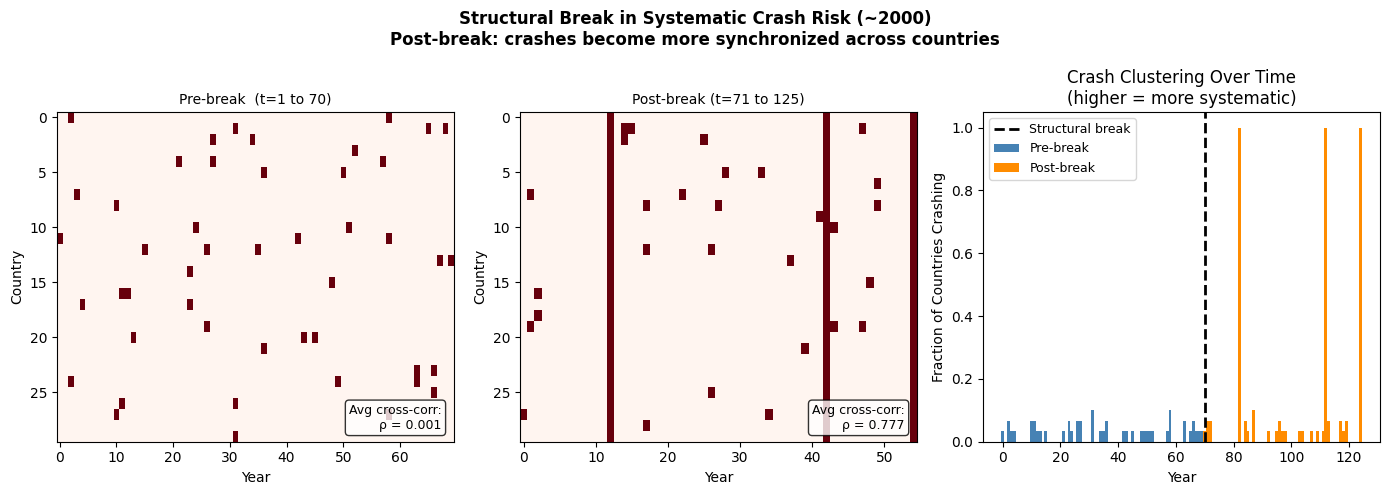

Average cross-country crash correlation
  Pre-break:  0.0015
  Post-break: 0.7771  (+0.7757)


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 2 – Structural Break in Systematic Crash Risk (~2000)
#
# Idea: The paper identifies a break around the turn of the century where the
# magnitude of *systematic* crash risk changed. Before ~2000, crashes were
# more idiosyncratic (country-specific). After, crashes became more correlated
# globally (systematic). We simulate this and show how an investor's belief
# about systematic risk should shift after observing the break.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_countries = 30
years_pre   = 70    # 1900–1969
years_post  = 55    # 1970–2024

# ── Regime parameters ─────────────────────────────────────────────────────────
# PRE-break: low systematic component, crashes mostly idiosyncratic
p_systematic_pre  = 0.01   # prob of a global crash year
p_idio_pre        = 0.025  # additional idiosyncratic crash prob per country

# POST-break: higher systematic component
p_systematic_post = 0.04
p_idio_post       = 0.015

def simulate_panel(n, years, p_sys, p_idio):
    """Returns (n x years) binary crash matrix."""
    systematic = (np.random.rand(years) < p_sys).astype(int)  # global crash years
    idio       = (np.random.rand(n, years) < p_idio).astype(int)
    # A country crashes if either the global or its own idio trigger fires
    crashes = np.clip(systematic[None, :] + idio, 0, 1)
    return crashes

crashes_pre  = simulate_panel(n_countries, years_pre,  p_systematic_pre,  p_idio_pre)
crashes_post = simulate_panel(n_countries, years_post, p_systematic_post, p_idio_post)

# ── Cross-country crash correlation (measures systemicness) ──────────────────
def cross_corr(crash_matrix):
    """Average pairwise correlation of crash indicators across countries.
    Drops zero-variance rows (countries that never crash) before computing."""
    varying = crash_matrix[crash_matrix.std(axis=1) > 0]
    if varying.shape[0] < 2:
        return 0.0
    corrs = np.corrcoef(varying)
    n = corrs.shape[0]
    mask = np.triu(np.ones((n, n), dtype=bool), k=1)
    return np.nanmean(corrs[mask])

rho_pre  = cross_corr(crashes_pre)
rho_post = cross_corr(crashes_post)

# ── Annual fraction of countries crashing (shows clustering post-break) ───────
frac_pre  = crashes_pre.mean(axis=0)    # one value per year
frac_post = crashes_post.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Structural Break in Systematic Crash Risk (~2000)\n"
             "Post-break: crashes become more synchronized across countries",
             fontsize=12, fontweight="bold")

# Panel 1 – crash synchronization heat-maps (pre vs post)
for idx, (mat, title, years) in enumerate([
        (crashes_pre,  f"Pre-break  (t=1 to {years_pre})",  years_pre),
        (crashes_post, f"Post-break (t={years_pre+1} to {years_pre+years_post})", years_post)]):
    ax = axes[idx]
    ax.imshow(mat, aspect="auto", cmap="Reds", vmin=0, vmax=1,
              interpolation="none")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Year"); ax.set_ylabel("Country")
    ax.text(0.97, 0.03, f"Avg cross-corr:\nρ = {cross_corr(mat):.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, bbox=dict(boxstyle="round", fc="white", alpha=0.8))

# Panel 3 – rolling fraction of countries crashing over the full timeline
ax = axes[2]
full_frac = np.concatenate([frac_pre, frac_post])
timeline  = np.arange(len(full_frac))
ax.bar(timeline[:years_pre],  frac_pre,  color="steelblue",  label="Pre-break",  width=1)
ax.bar(timeline[years_pre:],  frac_post, color="darkorange", label="Post-break", width=1)
ax.axvline(years_pre, color="black", ls="--", lw=2, label="Structural break")
ax.set_xlabel("Year"); ax.set_ylabel("Fraction of Countries Crashing")
ax.set_title("Crash Clustering Over Time\n(higher = more systematic)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Average cross-country crash correlation")
print(f"  Pre-break:  {rho_pre:.4f}")
print(f"  Post-break: {rho_post:.4f}  (+{rho_post - rho_pre:.4f})")

These three charts show what happens when stock market crashes stop being random, isolated events and start happening everywhere at once. The left and middle heat maps each show 30 countries (rows) over time (columns), where a dark red mark means that country had a crash that year. In the left chart, the pre-2000 period, the marks are scattered randomly across the grid with almost no pattern, and the correlation score in the corner is nearly zero (ρ = 0.001), meaning crashes were essentially independent events happening to individual countries for their own reasons. In the middle chart, the post-2000 period, you can immediately see thick vertical dark columns, which are years where nearly every country crashed at the same time. The correlation jumps to ρ = 0.777, meaning crashes became highly synchronized. The right chart reinforces this: each bar shows what fraction of all 30 countries crashed in a given year. Before the structural break (left of the dashed line), bars are short and spread out, small, idiosyncratic crashes here and there. After the break, you get sudden spikes reaching all the way to 1.0, meaning every single country crashed in the same year. The core idea from the paper is that this shift from idiosyncratic to systematic risk matters enormously, if crashes are now global events rather than local ones, no country is safe just because it hasn't crashed recently, and the US should no longer feel safe because of its own clean record.

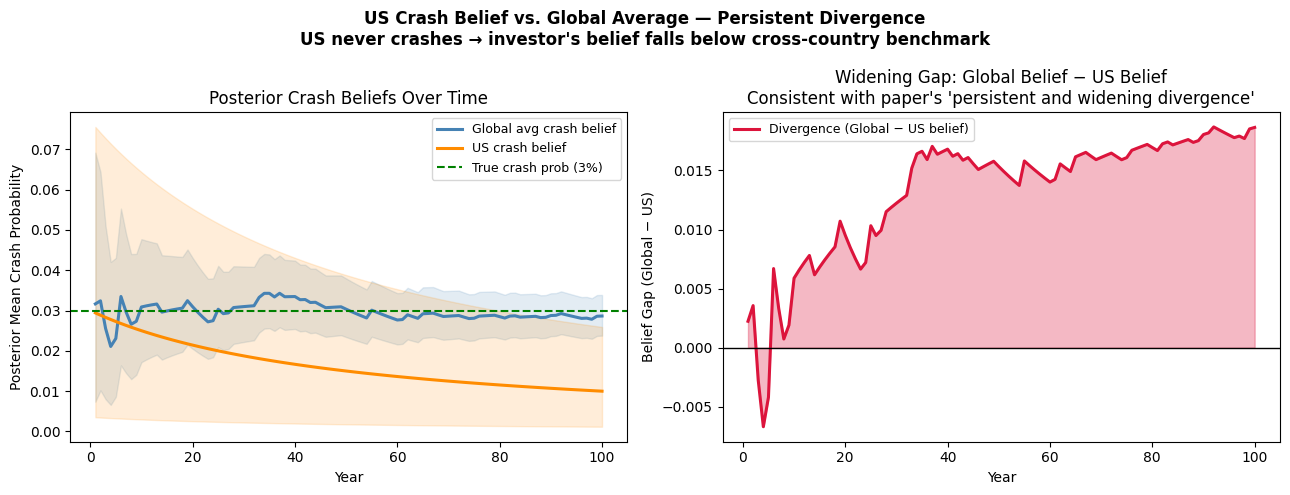

Year 1  divergence: 0.0022
Year 50 divergence: 0.0153
Year 100 divergence: 0.0186

Final US belief:     0.0100
Final global belief: 0.0286
True crash prob:     0.0300


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# BLOCK 3 – US Crash Belief Diverging from the Global Average
#
# Idea: As time passes without the US crashing, a Bayesian investor's belief
# about the US crash probability falls further and further below the
# cross-country implied global average. The gap is persistent and widens —
# consistent with the paper's finding of a "divergence in crash beliefs."
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

np.random.seed(42)

# ── Setup ─────────────────────────────────────────────────────────────────────
T             = 100          # years
true_p_global = 0.03
true_p_us     = 0.03         # US has the SAME true risk, it just never realizes it

n_other       = 29
a0, b0        = 1.5, 48.5   # shared prior mean ≈ 3%

# ── Simulate other-country crashes (give the investor global evidence) ────────
other_crashes = np.random.binomial(1, true_p_global, (n_other, T))

# ── US: lucky — no crashes in T years ────────────────────────────────────────
us_crashes = np.zeros(T, dtype=int)

# ── Year-by-year Bayesian updating ───────────────────────────────────────────
# Global posterior: updated with all countries (including US)
# US-only posterior: updated with US data alone
# Cross-learning posterior: use other countries first, then condition on US surviving

a_global, b_global = a0, b0
a_us,     b_us     = a0, b0

us_belief_means, global_belief_means = [], []
us_lo, us_hi, gl_lo, gl_hi = [], [], [], []

for t in range(T):
    # Global: observe all n_other countries this year
    a_global += other_crashes[:, t].sum()
    b_global += n_other - other_crashes[:, t].sum()

    # US: update with US data (no crash each year → +1 to b)
    a_us += us_crashes[t]
    b_us += 1 - us_crashes[t]

    # Store posterior means and 90% CI
    us_belief_means.append(a_us / (a_us + b_us))
    global_belief_means.append(a_global / (a_global + b_global))
    us_lo.append(beta_dist.ppf(0.05, a_us, b_us))
    us_hi.append(beta_dist.ppf(0.95, a_us, b_us))
    gl_lo.append(beta_dist.ppf(0.05, a_global, b_global))
    gl_hi.append(beta_dist.ppf(0.95, a_global, b_global))

us_belief_means    = np.array(us_belief_means)
global_belief_means = np.array(global_belief_means)
divergence          = global_belief_means - us_belief_means
years               = np.arange(1, T + 1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("US Crash Belief vs. Global Average — Persistent Divergence\n"
             "US never crashes → investor's belief falls below cross-country benchmark",
             fontsize=12, fontweight="bold")

# Panel 1 — belief paths
ax = axes[0]
ax.fill_between(years, gl_lo, gl_hi, alpha=0.15, color="steelblue")
ax.fill_between(years, us_lo, us_hi, alpha=0.15, color="darkorange")
ax.plot(years, global_belief_means, color="steelblue",  lw=2.2, label="Global avg crash belief")
ax.plot(years, us_belief_means,     color="darkorange", lw=2.2, label="US crash belief")
ax.axhline(true_p_global, color="green", ls="--", lw=1.5,
           label=f"True crash prob ({true_p_global:.0%})")
ax.set_xlabel("Year"); ax.set_ylabel("Posterior Mean Crash Probability")
ax.set_title("Posterior Crash Beliefs Over Time")
ax.legend(fontsize=9)

# Panel 2 — divergence
ax2 = axes[1]
ax2.fill_between(years, 0, divergence, alpha=0.3, color="crimson")
ax2.plot(years, divergence, color="crimson", lw=2.2, label="Divergence (Global − US belief)")
ax2.axhline(0, color="black", lw=1)
ax2.set_xlabel("Year"); ax2.set_ylabel("Belief Gap (Global − US)")
ax2.set_title("Widening Gap: Global Belief − US Belief\n"
              "Consistent with paper's 'persistent and widening divergence'")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Year 1  divergence: {divergence[0]:.4f}")
print(f"Year 50 divergence: {divergence[49]:.4f}")
print(f"Year 100 divergence: {divergence[99]:.4f}")
print(f"\nFinal US belief:     {us_belief_means[-1]:.4f}")
print(f"Final global belief: {global_belief_means[-1]:.4f}")
print(f"True crash prob:     {true_p_global:.4f}")

The left chart tracks two investors' beliefs about crash risk over 100 years. The blue line represents an investor looking at all 30 countries,  their estimate stays close to the true 3% (green dashed line) the whole time, because the global data keeps reminding them that crashes really do happen at that rate. The orange line is an investor looking only at the US, since the US never crashes in this simulation, every passing year of calm is new "evidence" that the US is safe, and their estimated crash probability drifts steadily downward from 3% all the way to around 1% by year 100. The shaded bands around each line show uncertainty, and notice the orange band shrinks over time, the US-only investor is becoming **increasingly confident** in the wrong answer. The right chart isolates just the gap between those two lines. In the very early years the gap bounces around near zero, but from around year 20 onward it opens up and keeps growing, reaching roughly 1.5 percentage points by year 100. This is the core illusion the paper is warning about: the longer the US goes without a crash, the more an investor relying only on US history will convince themselves that crashes are a thing that happens to other countries, not them, even though the true underlying risk never changed at all.